# 04 Regresion

Aqui predigo `nota_media_2sem` sin usar columnas del segundo semestre como entrada.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.preprocess_base import (
    cargar_data,
    limpieza_basica,
    permutar_filas,
    tratar_ceros_notas_sin_evaluacion,
)
from src.preprocess_regresion import get_regression_dataset
from src.regresion_lineal_propia import LinearRegressor, evaluate_regression
from src.utils import (
    PROJECT_PALETTE,
    adaptar_dataframe_a_sklearn,
    annotate_bars,
    set_project_style,
)
from src.validacion_cruzada_propia import cross_validation_supervised

warnings.filterwarnings("ignore", message="Found unknown categories in columns")
pd.set_option("display.max_columns", None)
set_project_style()
print("Proyecto:", PROJECT_ROOT.name)


Proyecto: student-academic-performance


## Planteamiento

- El target es `nota_media_2sem`.
- Si la nota es 0 y no hubo evaluaciones, no la uso como target.
- Comparo `early` y `sem1`.
- Uso una baseline de media y dos formas de ajustar regresion lineal.


In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
UNKNOWN_AS_MISSING = False
GD_LEARNING_RATE = 0.01
GD_ITERATIONS = 15000


def build_regression_preprocessor(X_train):
    numeric_cols = X_train.select_dtypes(include="number").columns.tolist()
    categorical_cols = X_train.select_dtypes(exclude="number").columns.tolist()

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ]
    )


def prepare_regression_data(stage):
    df = cargar_data()
    df = permutar_filas(df, random_state=RANDOM_STATE)
    df = limpieza_basica(df, desconocido_es_nan=UNKNOWN_AS_MISSING)
    df = tratar_ceros_notas_sin_evaluacion(df)
    df = df.convert_dtypes()
    df = adaptar_dataframe_a_sklearn(df)

    n_rows_after_cleaning = len(df)
    n_target_not_interpretable = int(df["nota_media_2sem"].isna().sum())

    X, y = get_regression_dataset(df, stage=stage, drop_missing_target=True)
    y = pd.to_numeric(y, errors="coerce").astype(float)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    preprocessor = build_regression_preprocessor(X_train)
    X_train_prepared = preprocessor.fit_transform(X_train)
    X_test_prepared = preprocessor.transform(X_test)

    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "preprocessor": preprocessor,
        "X_train_prepared": X_train_prepared,
        "X_test_prepared": X_test_prepared,
        "n_rows_after_cleaning": n_rows_after_cleaning,
        "n_target_valid": len(y),
        "n_target_not_interpretable": n_target_not_interpretable,
    }


def fit_regression_models(X_train_prepared, y_train):
    baseline_value = float(np.mean(y_train))
    baseline_pred = np.repeat(baseline_value, len(y_train))

    model_ls = LinearRegressor().fit(
        X_train_prepared,
        y_train.to_numpy(),
        method="least_squares",
    )

    model_gd = LinearRegressor().fit(
        X_train_prepared,
        y_train.to_numpy(),
        method="gradient_descent",
        learning_rate=GD_LEARNING_RATE,
        iterations=GD_ITERATIONS,
    )

    return baseline_value, model_ls, model_gd


regression_scorers = {
    metric: (lambda yt, yp, key=metric: evaluate_regression(yt, yp)[key])
    for metric in ["R2", "RMSE", "MAE"]
}


## Comparacion `early` y `sem1`

Primero miro si la informacion del primer semestre mejora la prediccion de la nota del segundo.


,stage,R2,RMSE,MAE
0,early,0.215,3.804,2.521
1,sem1,0.592,2.739,1.644


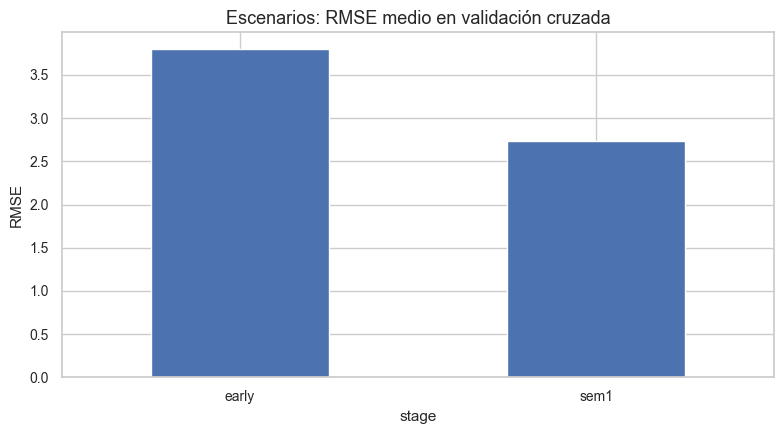

In [3]:
stage_rows = []
for stage in ["early", "sem1"]:
    stage_data = prepare_regression_data(stage)
    _, summary = cross_validation_supervised(
        model_factory=lambda: LinearRegressor(), X=stage_data["X_train"], y=stage_data["y_train"],
        preprocessor=stage_data["preprocessor"], n_folds=CV_FOLDS, task="regression",
        scorers=regression_scorers,
        fit_params={"method": "gradient_descent", "learning_rate": GD_LEARNING_RATE, "iterations": GD_ITERATIONS},
        random_state=RANDOM_STATE)
    stage_rows.append({"stage": stage, **summary.set_index("metric")["mean"].to_dict()})
df_stage_reg = pd.DataFrame(stage_rows)
display(df_stage_reg.round(3))
selected_stage = df_stage_reg.sort_values("RMSE").iloc[0]["stage"]
ax = df_stage_reg.set_index("stage")[["RMSE"]].plot.bar(rot=0, legend=False)
ax.set_title("Escenarios: RMSE medio en validación cruzada")
ax.set_ylabel("RMSE")
plt.tight_layout()
plt.show()


## Alcance del target

Las metricas se calculan solo sobre filas con nota del segundo semestre interpretable. No estoy prediciendo nota para todos los alumnos originales.


## Escenario principal

Se elige por RMSE medio en validación cruzada de entrenamiento. Después se comparan los dos métodos de ajuste dentro de ese escenario, antes de evaluar el test.


In [4]:
STAGE = selected_stage
data = prepare_regression_data(STAGE)

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]
preprocessor = data["preprocessor"]
X_train_prepared = data["X_train_prepared"]
X_test_prepared = data["X_test_prepared"]

print("Stage elegido:", STAGE)
print("X_train original:", X_train.shape)
print("X_test original:", X_test.shape)
print("X_train preparado:", X_train_prepared.shape)
print("X_test preparado:", X_test_prepared.shape)
print("Filas con target válido:", len(y_train) + len(y_test))


Stage elegido: sem1
X_train original: (3218, 30)
X_test original: (805, 30)
X_train preparado: (3218, 216)
X_test preparado: (805, 216)
Filas con target válido: 4023


## Validacion cruzada

Compruebo los modelos lineales con K-Fold dentro de train.


,metric,mean,std,modelo
0,R2,0.567,0.053,least_squares
1,RMSE,2.817,0.089,least_squares
2,MAE,1.707,0.025,least_squares
3,R2,0.592,0.038,gradient_descent
4,RMSE,2.739,0.077,gradient_descent
5,MAE,1.644,0.030,gradient_descent


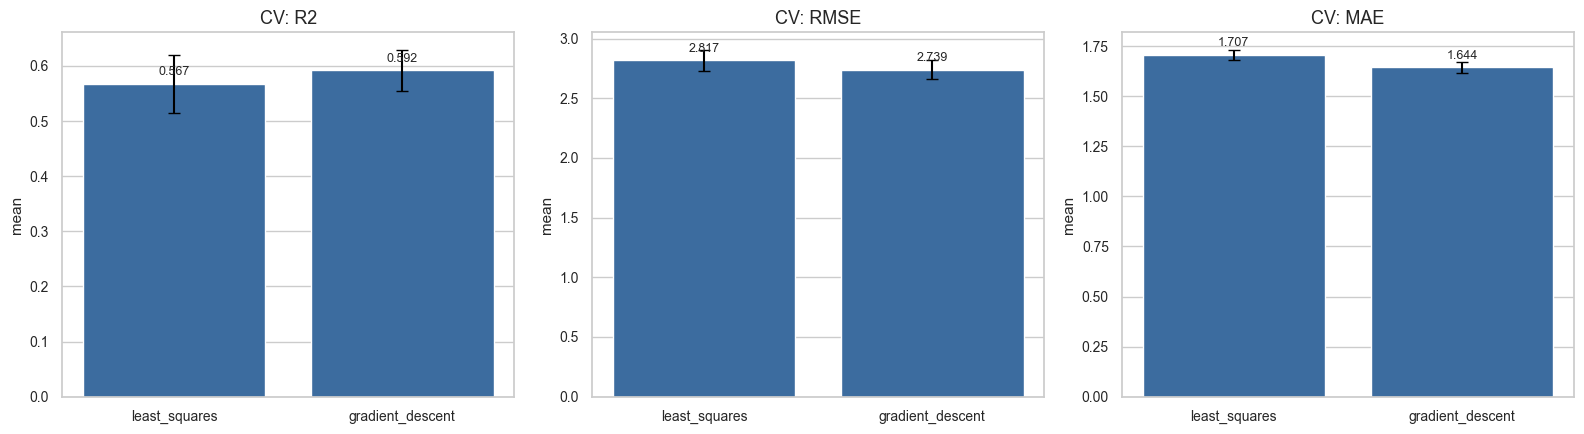

In [5]:
regression_scorers = {
    "R2": lambda y_true, y_pred: evaluate_regression(y_true, y_pred)["R2"],
    "RMSE": lambda y_true, y_pred: evaluate_regression(y_true, y_pred)["RMSE"],
    "MAE": lambda y_true, y_pred: evaluate_regression(y_true, y_pred)["MAE"],
}

_, cv_ls_summary = cross_validation_supervised(
    model_factory=lambda: LinearRegressor(),
    X=X_train,
    y=y_train,
    preprocessor=preprocessor,
    n_folds=CV_FOLDS,
    task="regression",
    scorers=regression_scorers,
    fit_params={"method": "least_squares"},
    random_state=RANDOM_STATE,
)

_, cv_gd_summary = cross_validation_supervised(
    model_factory=lambda: LinearRegressor(),
    X=X_train,
    y=y_train,
    preprocessor=preprocessor,
    n_folds=CV_FOLDS,
    task="regression",
    scorers=regression_scorers,
    fit_params={
        "method": "gradient_descent",
        "learning_rate": GD_LEARNING_RATE,
        "iterations": GD_ITERATIONS,
    },
    random_state=RANDOM_STATE,
)

cv_ls_summary["modelo"] = "least_squares"
cv_gd_summary["modelo"] = "gradient_descent"
cv_regresion = pd.concat([cv_ls_summary, cv_gd_summary], ignore_index=True)
display(cv_regresion.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric in zip(axes, ["R2", "RMSE", "MAE"]):
    subset = cv_regresion[cv_regresion["metric"] == metric]
    sns.barplot(
        data=subset,
        x="modelo",
        y="mean",
        color=PROJECT_PALETTE["primary"],
        ax=ax,
    )
    ax.set_title(f"CV: {metric}")
    ax.set_xlabel("")
    for _, row in subset.iterrows():
        xpos = 0 if row["modelo"] == "least_squares" else 1
        ax.errorbar(x=xpos, y=row["mean"], yerr=row["std"], fmt="none", ecolor="black", capsize=4)
    annotate_bars(ax)
plt.tight_layout()
plt.show()

selected_method = cv_regresion[cv_regresion["metric"] == "RMSE"].sort_values("mean").iloc[0]["modelo"]


,modelo,R2,RMSE,MAE
2,lineal_gradient_descent,0.666,2.434,1.476
1,lineal_least_squares,0.626,2.575,1.541
0,baseline_media,-0.003,4.218,2.791


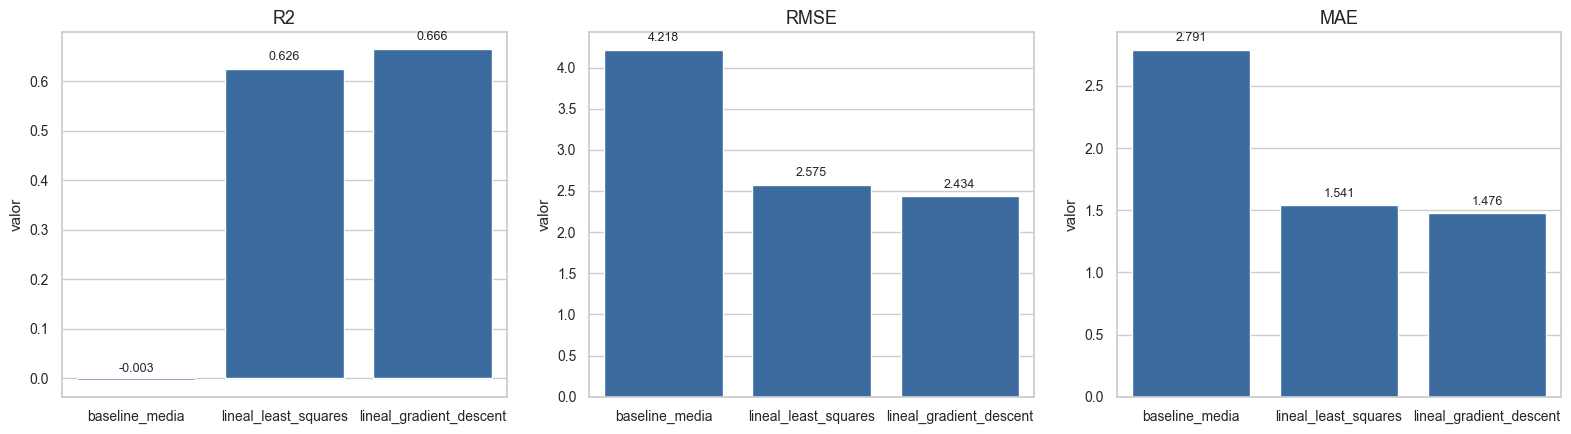

In [6]:
baseline_value, modelo_ls, modelo_gd = fit_regression_models(X_train_prepared, y_train)

y_pred_baseline = np.repeat(baseline_value, len(y_test))
y_pred_ls = modelo_ls.predict(X_test_prepared)
y_pred_gd = modelo_gd.predict(X_test_prepared)

comparacion = pd.DataFrame(
    [
        {"modelo": "baseline_media", **evaluate_regression(y_test.to_numpy(), y_pred_baseline)},
        {"modelo": "lineal_least_squares", **evaluate_regression(y_test.to_numpy(), y_pred_ls)},
        {"modelo": "lineal_gradient_descent", **evaluate_regression(y_test.to_numpy(), y_pred_gd)},
    ]
)
display(comparacion.sort_values("RMSE").round(3))

metric_plot = comparacion.melt(id_vars="modelo", value_vars=["R2", "RMSE", "MAE"], var_name="metrica", value_name="valor")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric in zip(axes, ["R2", "RMSE", "MAE"]):
    subset = metric_plot[metric_plot["metrica"] == metric]
    sns.barplot(data=subset, x="modelo", y="valor", color=PROJECT_PALETTE["primary"], ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("")
    annotate_bars(ax)
plt.tight_layout()
plt.show()


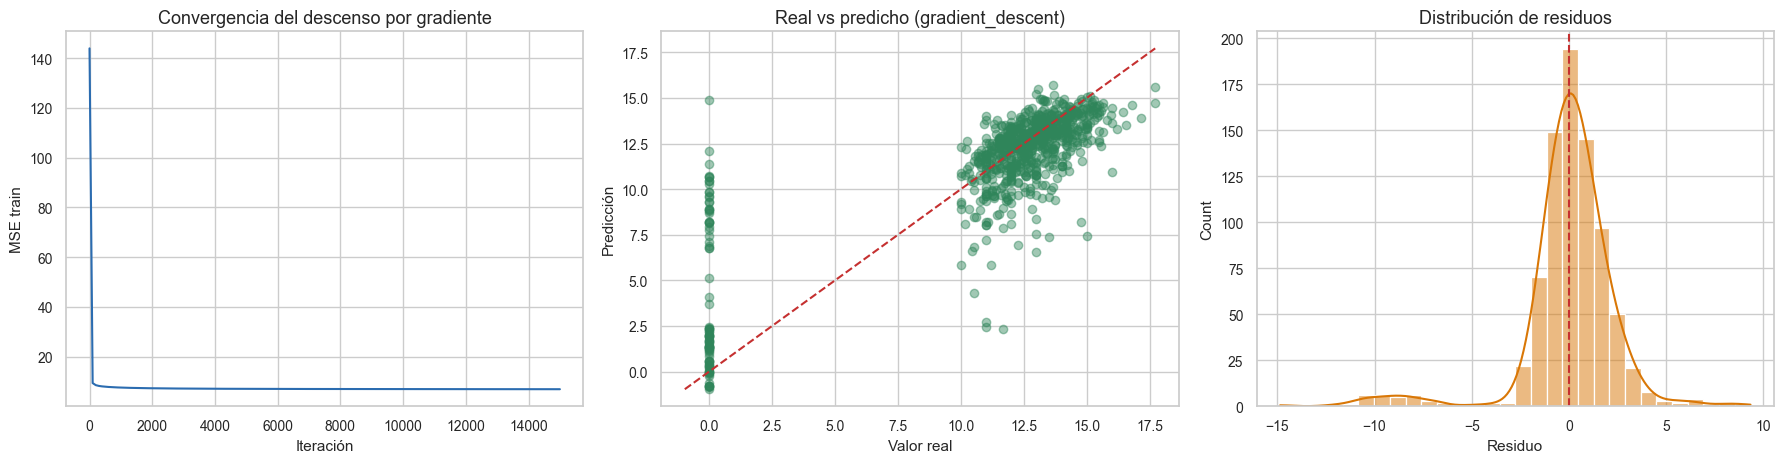

In [7]:
mejor_nombre = selected_method
mejor_pred = y_pred_gd if mejor_nombre == "gradient_descent" else y_pred_ls

loss_history = pd.DataFrame(modelo_gd.loss_history, columns=["iteracion", "mse"])

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

axes[0].plot(loss_history["iteracion"], loss_history["mse"], color=PROJECT_PALETTE["primary"])
axes[0].set_title("Convergencia del descenso por gradiente")
axes[0].set_xlabel("Iteración")
axes[0].set_ylabel("MSE train")

axes[1].scatter(y_test, mejor_pred, alpha=0.45, color=PROJECT_PALETTE["secondary"])
min_val = min(y_test.min(), mejor_pred.min())
max_val = max(y_test.max(), mejor_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], linestyle="--", color=PROJECT_PALETTE["danger"])
axes[1].set_title(f"Real vs predicho ({mejor_nombre})")
axes[1].set_xlabel("Valor real")
axes[1].set_ylabel("Predicción")

residuals = y_test.to_numpy() - mejor_pred
sns.histplot(residuals, bins=30, kde=True, color=PROJECT_PALETTE["accent"], ax=axes[2])
axes[2].axvline(0, linestyle="--", color=PROJECT_PALETTE["danger"])
axes[2].set_title("Distribución de residuos")
axes[2].set_xlabel("Residuo")

plt.tight_layout()
plt.show()


## Coeficientes

Miro solo los coeficientes numericos mas grandes para tener una idea general. No los interpreto como causas.


,coeficiente
num__asignaturas_1sem_matriculadas,-1.339
num__asignaturas_1sem_convalidadas,-0.344
num__tasa_desempleo,-0.173
num__orden_solicitud,-0.101
num__edad_al_matricularse,-0.084
num__nota_admision,0.088
num__pib,0.139
num__asignaturas_1sem_evaluadas,0.158
num__nota_media_1sem,1.749
num__asignaturas_1sem_aprobadas,2.486


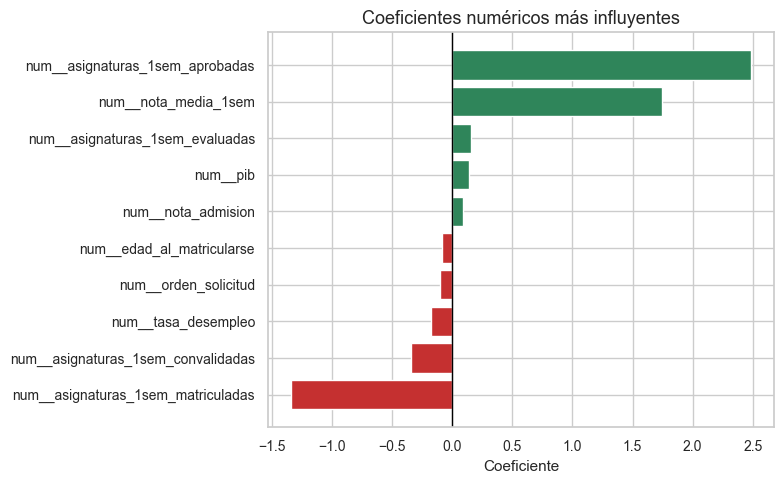

In [8]:
feature_names = preprocessor.get_feature_names_out()
coef_series = pd.Series(modelo_gd.coefficients, index=feature_names)
numeric_coef = coef_series[coef_series.index.str.startswith("num__")]
top_numeric_coef = numeric_coef.reindex(numeric_coef.abs().sort_values(ascending=False).head(10).index).sort_values()

display(top_numeric_coef.round(3).to_frame("coeficiente"))

plt.figure(figsize=(8, 5))
colors = [PROJECT_PALETTE["danger"] if x < 0 else PROJECT_PALETTE["secondary"] for x in top_numeric_coef.values]
plt.barh(top_numeric_coef.index, top_numeric_coef.values, color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Coeficientes numéricos más influyentes")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()


In [9]:
chosen_name = "lineal_" + selected_method
test_row = comparacion.set_index("modelo").loc[chosen_name]
cv_row = cv_regresion[cv_regresion["modelo"] == selected_method].set_index("metric")["mean"]
resumen_final_regresion = pd.DataFrame([
    {"apartado": "test", "modelo": chosen_name, **{m: test_row[m] for m in ["R2", "RMSE", "MAE"]}},
    {"apartado": "cv_train", "modelo": chosen_name, **{m: cv_row[m] for m in ["R2", "RMSE", "MAE"]}},
])
display(resumen_final_regresion.round(3))
print("Escenario elegido en CV:", STAGE)
print("Filas con target válido:", data["n_target_valid"])
print("Filas excluidas:", data["n_target_not_interpretable"])


Escenario elegido en CV: sem1
Filas con target válido: 4023
Filas excluidas: 401


,apartado,modelo,R2,RMSE,MAE
0,test,lineal_gradient_descent,0.666,2.434,1.476
1,cv_train,lineal_gradient_descent,0.592,2.739,1.644


## Conclusiones y alcance

La selección del escenario y del método de ajuste utiliza validación cruzada en entrenamiento. El test se evalúa después. Una diferencia entre descenso por gradiente y mínimos cuadrados puede reflejar convergencia, condicionamiento o regularización implícita; no establece una superioridad general.

Las métricas excluyen filas con nota cero y cero evaluaciones, según la hipótesis de limpieza del proyecto. Esta decisión necesita validación de dominio. Se reutiliza el split de la entrega: los resultados son retrospectivos y requieren validación en nuevas cohortes.


## Exportar resultados

Tablas reproducibles para el resumen del repositorio.

In [10]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
comparacion.to_csv(RESULTS_DIR / "regression_test.csv", index=False)
cv_regresion.to_csv(RESULTS_DIR / "regression_cv.csv", index=False)
resumen_final_regresion.to_csv(RESULTS_DIR / "regression_summary.csv", index=False)
df_stage_reg.to_csv(RESULTS_DIR / "regression_stages_cv.csv", index=False)
